In [1]:

# load, Explore and Plot the Data
import numpy as np
import pandas as pd
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt

# suppress display of warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
## Reading the given dataset
data = pd.read_excel("/content/spam_ham_dataset.csv.xlsx", names=["label", "message"])

In [3]:
data.head()

,label,message
0,ham,Subject: enron methanol ; meter # : 988291_x00...
1,ham,"Subject: hpl nom for january 9 , 2001_x000D_\n..."
2,ham,"Subject: neon retreat_x000D_\nho ho ho , we ' ..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs_x000D_\nthis deal...


In [4]:
data.shape

(5171, 2)

In [5]:
# Checking for null values
data.isnull().sum()

,0
label,0
message,0


In [6]:
# Checking for duplicate values
data.duplicated().sum()

np.int64(178)

*178 duplicate rows found in the dataset and need to remove them.*

In [7]:
# Drop duplicates
data = data.drop_duplicates()

In [8]:
data.duplicated().sum()

np.int64(0)

# **Now, Data Analysis**

In [9]:
data['label'].value_counts()

,count
label,
ham,3531
spam,1462


([<matplotlib.patches.Wedge at 0x78d992362c50>,
 [Text(-0.6664987851717366, 0.8750882066195381, 'ham'),
  Text(0.6664990703116317, -0.8750879894466217, 'spam')],
 [Text(-0.36354479191185624, 0.4773208399742935, '70.72'),
  Text(0.36354494744270816, -0.47732072151633903, '29.28')])

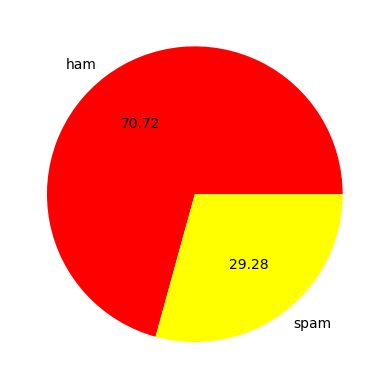

In [10]:
plt.pie(data['label'].value_counts(), labels = ['ham', 'spam'], colors = ['Red', 'yellow'], autopct='%0.2f')

**So, we can observe that dataset has 70.72% ham messages whereas 29.28% messages are spam.**

In [11]:
# 1st meassage
data['message'][0]

"Subject: enron methanol ; meter # : 988291_x000D_\nthis is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary_x000D_\nflow data provided by daren } ._x000D_\nplease override pop ' s daily volume { presently zero } to reflect daily_x000D_\nactivity you can obtain from gas control ._x000D_\nthis change is needed asap for economics purposes ."

In [12]:
# total no. of characters
data['num_characters'] = data['message'].apply(len)


In [13]:
data.head()

,label,message,num_characters
0,ham,Subject: enron methanol ; meter # : 988291_x00...,357
1,ham,"Subject: hpl nom for january 9 , 2001_x000D_\n...",109
2,ham,"Subject: neon retreat_x000D_\nho ho ho , we ' ...",2578
3,spam,"Subject: photoshop , windows , office . cheap ...",474
4,ham,Subject: re : indian springs_x000D_\nthis deal...,360


In [14]:
import nltk # Natural Language Toolkit
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [15]:
# words tokenization
data['message'].apply(lambda x: nltk.word_tokenize(x))

,message
0,"[Subject, :, enron, methanol, ;, meter, #, :, ..."
1,"[Subject, :, hpl, nom, for, january, 9, ,, 200..."
2,"[Subject, :, neon, retreat_x000D_, ho, ho, ho,..."
3,"[Subject, :, photoshop, ,, windows, ,, office,..."
4,"[Subject, :, re, :, indian, springs_x000D_, th..."
...,...
5165,"[Subject, :, fw, :, crosstex, energy, ,, drisc..."
5166,"[Subject, :, put, the, 10, on, the, ft_x000D_,..."
5167,"[Subject, :, 3, /, 4, /, 2000, and, following,..."
5169,"[Subject, :, industrial, worksheets, for, augu..."


In [16]:
# total no. of words
data['num_words'] = data['message'].apply(lambda x:len(nltk.word_tokenize(x)))
data.head()

,label,message,num_characters,num_words
0,ham,Subject: enron methanol ; meter # : 988291_x00...,357,68
1,ham,"Subject: hpl nom for january 9 , 2001_x000D_\n...",109,25
2,ham,"Subject: neon retreat_x000D_\nho ho ho , we ' ...",2578,554
3,spam,"Subject: photoshop , windows , office . cheap ...",474,49
4,ham,Subject: re : indian springs_x000D_\nthis deal...,360,71


In [17]:
# Number of sentences
data['num_sentences']=data['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [18]:
data.head()

,label,message,num_characters,num_words,num_sentences
0,ham,Subject: enron methanol ; meter # : 988291_x00...,357,68,1
1,ham,"Subject: hpl nom for january 9 , 2001_x000D_\n...",109,25,3
2,ham,"Subject: neon retreat_x000D_\nho ho ho , we ' ...",2578,554,17
3,spam,"Subject: photoshop , windows , office . cheap ...",474,49,3
4,ham,Subject: re : indian springs_x000D_\nthis deal...,360,71,3


In [19]:
# Ham messages
data[data['label'] == 'ham'][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,3531.000000,3531.000000,3531.000000
mean,1102.684509,233.583687,8.690456
std,1541.521623,343.040088,23.755892
min,24.000000,3.000000,1.000000
25%,269.000000,54.000000,3.000000
50%,604.000000,129.000000,5.000000
75%,1393.500000,303.000000,10.000000
max,34646.000000,9246.000000,1201.000000


In [20]:
# Spam messages
data[data['label']=='spam'][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,1462.000000,1462.000000,1462.000000
mean,1378.867989,244.303010,13.852941
std,2000.128749,351.578522,31.627618
min,17.000000,3.000000,1.000000
25%,351.000000,62.000000,3.000000
50%,666.000000,122.000000,6.000000
75%,1456.000000,255.250000,13.000000
max,24017.000000,3967.000000,680.000000


We can clearly see that spam messages have more characters and words comapare to ham messages.

<Axes: xlabel='num_characters', ylabel='Count'>

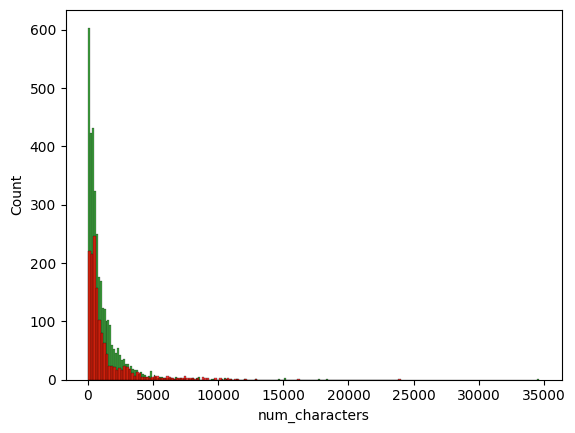

In [21]:
plt.figure()
sns.histplot(data[data['label'] == 'ham']['num_characters'],color ='green')
sns.histplot(data[data['label'] == 'spam']['num_characters'],color = 'red')

<Axes: xlabel='num_words', ylabel='Count'>

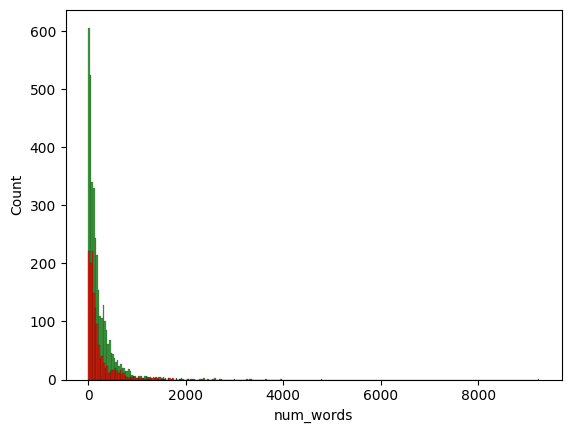

In [22]:
# for words
plt.figure()
sns.histplot(data[data['label'] == 'ham']['num_words'],color = 'green')
sns.histplot(data[data['label'] == 'spam']['num_words'],color = 'red')

# **Word Cloud**

In [23]:
!pip install wordcloud

In [24]:
from wordcloud import WordCloud

In [25]:
ham_msg_text = data[data.label == 'ham'].message
spam_msg_text = data[data.label == 'spam'].message

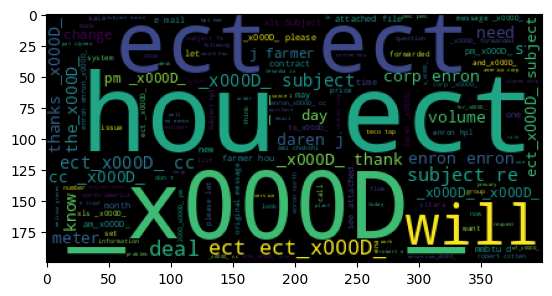

In [26]:
## Word Cloud for Ham messages

plt.figure()

wc = WordCloud().generate(" ".join(ham_msg_text))
plt.imshow(wc)

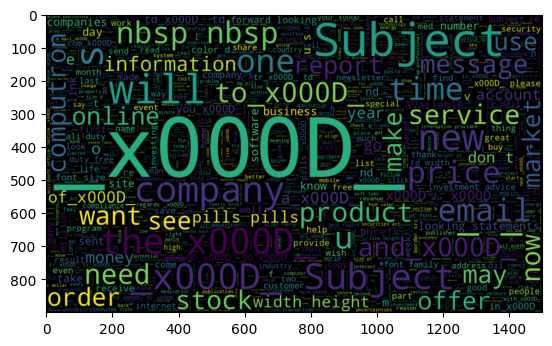

In [27]:
## Word Cloud for Spam MSGs

plt.figure()

wc = WordCloud(width = 1500, height = 900, max_words = 2500).generate(" ".join(spam_msg_text))
plt.imshow(wc, interpolation='bilinear')

# **Data Pre-Processing**

In [28]:
data['message'][5]


'Subject: ehronline web address change_x000D_\nthis message is intended for ehronline users only ._x000D_\ndue to a recent change to ehronline , the url ( aka " web address " ) for accessing ehronline needs to be changed on your computer . the change involves adding the letter " s " to the " http " reference in the url . the url for accessing ehronline should be : https : / / ehronline . enron . com ._x000D_\nthis change should be made by those who have added the url as a favorite on the browser .'

1. Remove Punctuation

In [29]:
def remove_punc(text):
  trans = str.maketrans('', '', string.punctuation)
  return text.translate(trans)

In [30]:
data['message'] = data['message'].apply(remove_punc)

In [31]:
data['message'][5]

'Subject ehronline web address changex000D\nthis message is intended for ehronline users only x000D\ndue to a recent change to ehronline  the url  aka  web address   for accessing ehronline needs to be changed on your computer  the change involves adding the letter  s  to the  http  reference in the url  the url for accessing ehronline should be  https    ehronline  enron  com x000D\nthis change should be made by those who have added the url as a favorite on the browser '

2. Remove Special Characters

In [32]:
def remove_noise(text):
  t = re.sub('[^a-zA-Z]', ' ', text)
  return t

In [33]:
data['message'] = data['message'].apply(remove_noise)

In [34]:
data['message'][5]

'Subject ehronline web address changex   D this message is intended for ehronline users only x   D due to a recent change to ehronline  the url  aka  web address   for accessing ehronline needs to be changed on your computer  the change involves adding the letter  s  to the  http  reference in the url  the url for accessing ehronline should be  https    ehronline  enron  com x   D this change should be made by those who have added the url as a favorite on the browser '

3. Remove Stopwords

In [35]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [36]:
from nltk.corpus import stopwords
sw = stopwords.words('english')

In [37]:
sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [38]:
def remove_sws(text):
  s = [word.lower() for word in text.split() if word.lower() not in sw]
  return " ".join(s)

In [39]:
data['message'] = data['message'].apply(remove_sws)

In [40]:
data['message'][5]

'subject ehronline web address changex message intended ehronline users x due recent change ehronline url aka web address accessing ehronline needs changed computer change involves adding letter http reference url url accessing ehronline https ehronline enron com x change made added url favorite browser'

4. Lemmatization

In [41]:
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [42]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def lemma(text):
  l = [lemmatizer.lemmatize(word) for word in text.split()]
  return " ".join(l)

In [43]:
data['message'] = data['message'].apply(lemma)

In [44]:
data['message'][5]

'subject ehronline web address changex message intended ehronline user x due recent change ehronline url aka web address accessing ehronline need changed computer change involves adding letter http reference url url accessing ehronline http ehronline enron com x change made added url favorite browser'

In [45]:
data.head()

,label,message,num_characters,num_words,num_sentences
0,ham,subject enron methanol meter x follow note gav...,357,68,1
1,ham,subject hpl nom january x see attached file hp...,109,25,3
2,ham,subject neon retreatx ho ho ho around wonderfu...,2578,554,17
3,spam,subject photoshop window office cheap main tre...,474,49,3
4,ham,subject indian springsx deal book teco pvr rev...,360,71,3


5. Label Encoder

In [46]:
from sklearn.preprocessing import LabelEncoder
encoder =LabelEncoder()

data['label']=encoder.fit_transform(data['label'])

In [47]:
data.head()

,label,message,num_characters,num_words,num_sentences
0,0,subject enron methanol meter x follow note gav...,357,68,1
1,0,subject hpl nom january x see attached file hp...,109,25,3
2,0,subject neon retreatx ho ho ho around wonderfu...,2578,554,17
3,1,subject photoshop window office cheap main tre...,474,49,3
4,0,subject indian springsx deal book teco pvr rev...,360,71,3


In [48]:
# Select only the relevant columns for building model

data = data[['label','message']]

In [49]:
data.head()

,label,message
0,0,subject enron methanol meter x follow note gav...
1,0,subject hpl nom january x see attached file hp...
2,0,subject neon retreatx ho ho ho around wonderfu...
3,1,subject photoshop window office cheap main tre...
4,0,subject indian springsx deal book teco pvr rev...


# **3. Feature Extraction for Converting Word to Vectors**
*Apply TF-IDF Vectorizer to convert word into Vectors.*

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf = TfidfVectorizer(max_features=3000)

In [51]:
X = tf.fit_transform(data['message']).toarray()
Y = data['label']

In [52]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [53]:
Y

,label
0,0
1,0
2,0
3,1
4,0
...,...
5165,0
5166,0
5167,0
5169,0


In [54]:
# Splitting the data into train and test

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 32)

In [55]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((3994, 3000), (999, 3000), (3994,), (999,))

# **4. Model Building & Evaluation**

In [56]:
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [57]:
# Create the instance of Naive Bayes
clf = BernoulliNB()

In [58]:
# Fit the data
clf.fit(X_train, Y_train)

BernoulliNB()

In [59]:
# Making prediction
Y_pred = clf.predict(X_test)

In [60]:
# Evaluation
print("Accuracy Score: ", accuracy_score(Y_test, Y_pred))

Accuracy Score:  0.9279279279279279


In [61]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       703
           1       0.86      0.90      0.88       296

    accuracy                           0.93       999
   macro avg       0.91      0.92      0.91       999
weighted avg       0.93      0.93      0.93       999



Text(120.72222222222221, 0.5, 'Truth')

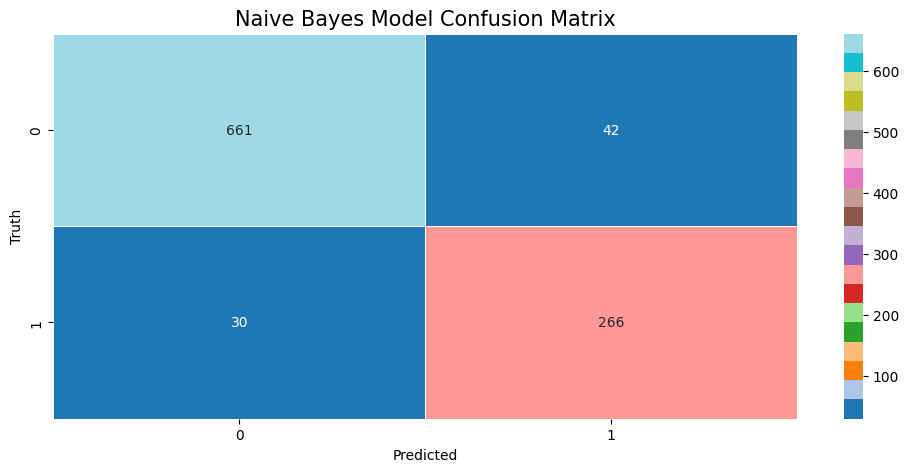

In [62]:
# Plot the Confusion Matrix

import seaborn as sn
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize = (12,5))
sn.heatmap(cm, annot=True,linewidth = 0.5 , cmap = 'tab20' , fmt='d')
plt.title('Naive Bayes Model Confusion Matrix', size=15)
plt.xlabel('Predicted')
plt.ylabel('Truth')

## **5. Save the Model**

In [63]:
import pickle
pickle.dump(tf,open('vectorizer.pkl','wb'))
pickle.dump(clf,open('model.pkl','wb'))

In [64]:
!pip install streamlit -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.4 MB/s eta 0:00:00


In [65]:
!wget -q -O - ipv4.icanhazip.com

35.196.32.79


In [68]:
! streamlit run app.py & npx localtunnel --port 8501

y
ok
Ok
35.196.32.79


⠙⠹⠸
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.196.32.79:8501

⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://old-knives-pay.loca.lt
Y
ok
Ok
  Stopping...
^C
